# 04 - Imbalanced Data Handling 

This notebook evaluates imbalance handling strategies for binary sentiment classification on Kingshot reviews.

This notebook continues from:

```text
02_preprocessing_and_filtering_kingshot_reviews_binary.ipynb
03_sentiment_classification_tfidf_ngram.ipynb
```

Experiment focus:

```text
1. Baseline models without balancing
2. Models with class_weight="balanced"
3. Random OverSampling
4. SMOTE
```

Visualization focus:

```text
1. Class distribution before modeling
2. Macro-F1 comparison across all experiments
3. Performance comparison before and after imbalance handling
4. Metric changes after imbalance handling
5. Confusion matrix comparison before and after imbalance handling
6. Final model selection summary
```

Input:

```text
data/processed/kingshot_reviews_processed.csv
```

Outputs:

```text
outputs/tables/imbalance_class_distribution.xlsx
outputs/tables/imbalance_model_comparison.xlsx
outputs/tables/imbalance_classification_reports.xlsx
outputs/tables/imbalance_cross_validation_results.xlsx
outputs/tables/final_model_selection_summary.xlsx
outputs/figures/imbalance_class_distribution.png
outputs/figures/imbalance_model_f1_macro_comparison_clean.png
outputs/figures/before_after_imbalance_metrics.png
outputs/figures/metric_changes_after_imbalance.png
outputs/figures/confusion_matrix_before_after_imbalance.png
outputs/figures/imbalance_confusion_matrix_best_model.png
```


## 1. Import Libraries and Define Configuration

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

warnings.filterwarnings("ignore")

APP_NAME = "kingshot"
RANDOM_STATE = 42

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() in ["notebook", "notebooks"]:
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

PROCESSED_DIR = BASE_DIR / "data" / "processed"
TABLE_DIR = BASE_DIR / "outputs" / "tables"
FIGURE_DIR = BASE_DIR / "outputs" / "figures"

for folder in [TABLE_DIR, FIGURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 100)

print("CURRENT_DIR  :", CURRENT_DIR)
print("BASE_DIR     :", BASE_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("TABLE_DIR    :", TABLE_DIR)
print("FIGURE_DIR   :", FIGURE_DIR)


CURRENT_DIR  : d:\Github\kingshot-review-sentiment-analysis\notebook
BASE_DIR     : d:\Github\kingshot-review-sentiment-analysis
PROCESSED_DIR: d:\Github\kingshot-review-sentiment-analysis\data\processed
TABLE_DIR    : d:\Github\kingshot-review-sentiment-analysis\outputs\tables
FIGURE_DIR   : d:\Github\kingshot-review-sentiment-analysis\outputs\figures


## 2. Load Processed Dataset

The processed dataset is generated by Notebook 02. The notebook uses the `clean_text` column as input text and the `sentiment` column as the target label.


In [2]:
processed_file = PROCESSED_DIR / f"{APP_NAME}_reviews_processed.csv"

if not processed_file.exists():
    raise FileNotFoundError(
        f"File tidak ditemukan: {processed_file}\n"
        "Jalankan notebook 02 terlebih dahulu."
    )

df = pd.read_csv(processed_file)
df = df.dropna(subset=["clean_text", "sentiment"]).copy()
df = df[df["sentiment"].isin(["negative", "positive"])].copy()

print("Ukuran data:", df.shape)
display(df[["review_text", "clean_text", "rating", "sentiment"]].head())
display(df["sentiment"].value_counts())


Ukuran data: (9640, 17)


,review_text,clean_text,rating,sentiment
0,once again the game is nothing like the ads!! so dumb,once again the game is nothing like the ads so dumb,1,negative
1,"if you are familiar with rise of kingdoms or the mobile age of empires game it's similar to that, very pay 2 win, if you are free to play, you will have no shot and will essentially be fodder. obv...",if you are familiar with rise of kingdoms or the mobile age of empires game it s similar to that very pay 2 win if you are free to play you will have no shot and will essentially be fodder obvious...,1,negative
2,This game has the most intrusive ads that force you to this page to download it,this game has the most intrusive ads that force you to this page to download it,1,negative
3,this game is NOTHING like the ads. this company and the thirsty influencers need to be held accountable. this is basically a multi player castle and unit game that will require money to be competi...,this game is nothing like the ads this company and the thirsty influencers need to be held accountable this is basically a multi player castle and unit game that will require money to be competiti...,1,negative
4,"games actually not bad, has a whole story line. thought it was some dumb ad that kept popping up. it's not though pretty addictive game.",games actually not bad has a whole story line thought it was some dumb ad that kept popping up it s not though pretty addictive game,5,positive


sentiment
negative    6243
positive    3397
Name: count, dtype: int64

## 3. Inspect Class Distribution

This section calculates the class distribution and saves an article-ready class distribution figure.


In [3]:
class_distribution = (
    df["sentiment"]
    .value_counts()
    .rename_axis("sentiment")
    .reset_index(name="count")
)

class_distribution["percentage"] = class_distribution["count"] / class_distribution["count"].sum()

majority_count = class_distribution["count"].max()
minority_count = class_distribution["count"].min()
imbalance_ratio = majority_count / minority_count

summary_distribution = pd.DataFrame({
    "metric": ["total_data", "majority_class_count", "minority_class_count", "imbalance_ratio"],
    "value": [len(df), majority_count, minority_count, imbalance_ratio]
})

display(class_distribution)
display(summary_distribution)

distribution_file = TABLE_DIR / "imbalance_class_distribution.xlsx"

with pd.ExcelWriter(distribution_file) as writer:
    class_distribution.to_excel(writer, sheet_name="class_distribution", index=False)
    summary_distribution.to_excel(writer, sheet_name="summary", index=False)

print(f"Distribusi kelas disimpan ke: {distribution_file}")


,sentiment,count,percentage
0,negative,6243,0.647614
1,positive,3397,0.352386


,metric,value
0,total_data,9640.000000
1,majority_class_count,6243.000000
2,minority_class_count,3397.000000
3,imbalance_ratio,1.837798


Distribusi kelas disimpan ke: d:\Github\kingshot-review-sentiment-analysis\outputs\tables\imbalance_class_distribution.xlsx


## 4. Create Train-Test Split

A stratified split is used so the class proportions are preserved in both training and test sets.


In [4]:
X = df["clean_text"].astype(str)
y = df["sentiment"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

display(y_train.value_counts())
display(y_test.value_counts())


Train: (7712,)
Test : (1928,)


sentiment
negative    4994
positive    2718
Name: count, dtype: int64

sentiment
negative    1249
positive     679
Name: count, dtype: int64

## 5. Define TF-IDF Vectorizer and Classification Models

All experiments use TF-IDF n-gram features. The evaluated models include Logistic Regression, Linear SVM, and Naive Bayes, with additional imbalance handling strategies where appropriate.


In [5]:
tfidf_params = {
    "max_features": 15000,
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "stop_words": "english"
}

experiments = {
    "Logistic Regression": SklearnPipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),

    "Linear SVM": SklearnPipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("model", LinearSVC(random_state=RANDOM_STATE))
    ]),

    "Naive Bayes": SklearnPipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("model", MultinomialNB())
    ]),

    "Logistic Regression Balanced": SklearnPipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Linear SVM Balanced": SklearnPipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("model", LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Logistic Regression RandomOverSampler": ImbPipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),

    "Linear SVM RandomOverSampler": ImbPipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", LinearSVC(random_state=RANDOM_STATE))
    ]),

    "Logistic Regression SMOTE": ImbPipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("sampler", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),

    "Linear SVM SMOTE": ImbPipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("sampler", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", LinearSVC(random_state=RANDOM_STATE))
    ])
}

model_short_names = {
    "Logistic Regression": "LR",
    "Linear SVM": "SVM",
    "Naive Bayes": "NB",
    "Logistic Regression Balanced": "LR-Bal",
    "Linear SVM Balanced": "SVM-Bal",
    "Logistic Regression RandomOverSampler": "LR-ROS",
    "Linear SVM RandomOverSampler": "SVM-ROS",
    "Logistic Regression SMOTE": "LR-SMOTE",
    "Linear SVM SMOTE": "SVM-SMOTE"
}

print("Jumlah eksperimen:", len(experiments))
for name in experiments:
    print("-", name)


Jumlah eksperimen: 9
- Logistic Regression
- Linear SVM
- Naive Bayes
- Logistic Regression Balanced
- Linear SVM Balanced
- Logistic Regression RandomOverSampler
- Linear SVM RandomOverSampler
- Logistic Regression SMOTE
- Linear SVM SMOTE


## 6. Train and Evaluate Models on the Holdout Test Set

Each model is trained using the same train-test split. The evaluation includes accuracy, precision, recall, macro-F1, weighted-F1, and confusion matrix values.


In [6]:
evaluation_rows = []
report_rows = []
trained_models = {}
predictions = {}

for model_name, pipeline in experiments.items():
    print(f"Training: {model_name}")

    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    y_pred = pipeline.predict(X_test)
    predictions[model_name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=["negative", "positive"],
        average=None,
        zero_division=0
    )

    evaluation_rows.append({
        "model": model_name,
        "short_model": model_short_names.get(model_name, model_name),
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "precision_negative": precision_per_class[0],
        "recall_negative": recall_per_class[0],
        "f1_negative": f1_per_class[0],
        "precision_positive": precision_per_class[1],
        "recall_positive": recall_per_class[1],
        "f1_positive": f1_per_class[1]
    })

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "label"})
    report_df["model"] = model_name
    report_df["short_model"] = model_short_names.get(model_name, model_name)
    report_rows.append(report_df)

evaluation_df = pd.DataFrame(evaluation_rows).sort_values(
    by=["f1_macro", "recall_positive", "accuracy"],
    ascending=False
).reset_index(drop=True)

classification_reports_df = pd.concat(report_rows, ignore_index=True)

display(evaluation_df)
display(classification_reports_df.head())


Training: Logistic Regression
Training: Linear SVM
Training: Naive Bayes
Training: Logistic Regression Balanced
Training: Linear SVM Balanced
Training: Logistic Regression RandomOverSampler
Training: Linear SVM RandomOverSampler
Training: Logistic Regression SMOTE
Training: Linear SVM SMOTE


,model,short_model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,precision_negative,recall_negative,f1_negative,precision_positive,recall_positive,f1_positive
0,Logistic Regression RandomOverSampler,LR-ROS,0.897822,0.891681,0.882490,0.886743,0.897184,0.897822,0.897215,0.910296,0.934347,0.922165,0.873065,0.830633,0.851321
1,Logistic Regression Balanced,LR-Bal,0.896784,0.890263,0.881690,0.885675,0.896145,0.896784,0.896211,0.910156,0.932746,0.921313,0.870370,0.830633,0.850038
2,Linear SVM,SVM,0.895747,0.892427,0.876520,0.883505,0.895210,0.895747,0.894670,0.901840,0.941553,0.921269,0.883013,0.811487,0.845741
3,Linear SVM Balanced,SVM-Bal,0.894191,0.887235,0.879016,0.882845,0.893528,0.894191,0.893624,0.908522,0.930344,0.919304,0.865948,0.827688,0.846386
4,Logistic Regression SMOTE,LR-SMOTE,0.892635,0.883803,0.879831,0.881748,0.892193,0.892635,0.892356,0.912184,0.923139,0.917628,0.855422,0.836524,0.845867
5,Linear SVM RandomOverSampler,SVM-ROS,0.893154,0.886074,0.877879,0.881696,0.892479,0.893154,0.892581,0.907740,0.929544,0.918513,0.864407,0.826215,0.844880
6,Logistic Regression,LR,0.894191,0.901850,0.864902,0.878956,0.896379,0.894191,0.891652,0.883346,0.963971,0.921899,0.920354,0.765832,0.836013
7,Linear SVM SMOTE,SVM-SMOTE,0.886929,0.876810,0.874756,0.875764,0.886653,0.886929,0.886775,0.910103,0.915933,0.913009,0.843517,0.833579,0.838519
8,Naive Bayes,NB,0.889523,0.906219,0.853233,0.871445,0.895355,0.889523,0.885697,0.869472,0.975981,0.919653,0.942966,0.730486,0.823237


,label,precision,recall,f1-score,support,model,short_model
0,negative,0.883346,0.963971,0.921899,1249.000000,Logistic Regression,LR
1,positive,0.920354,0.765832,0.836013,679.000000,Logistic Regression,LR
2,accuracy,0.894191,0.894191,0.894191,0.894191,Logistic Regression,LR
3,macro avg,0.901850,0.864902,0.878956,1928.000000,Logistic Regression,LR
4,weighted avg,0.896379,0.894191,0.891652,1928.000000,Logistic Regression,LR


## 7. Cross-Validation

Five-fold stratified cross-validation is used to evaluate model stability beyond the single holdout test split.


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "recall_macro": "recall_macro"
}

cv_rows = []

for model_name, pipeline in experiments.items():
    print(f"Cross-validation: {model_name}")

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_rows.append({
        "model": model_name,
        "short_model": model_short_names.get(model_name, model_name),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
        "f1_weighted_mean": scores["test_f1_weighted"].mean(),
        "f1_weighted_std": scores["test_f1_weighted"].std(),
        "recall_macro_mean": scores["test_recall_macro"].mean(),
        "recall_macro_std": scores["test_recall_macro"].std()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(
    by=["f1_macro_mean", "recall_macro_mean", "accuracy_mean"],
    ascending=False
).reset_index(drop=True)

display(cv_results_df)


Cross-validation: Logistic Regression
Cross-validation: Linear SVM
Cross-validation: Naive Bayes
Cross-validation: Logistic Regression Balanced
Cross-validation: Linear SVM Balanced
Cross-validation: Logistic Regression RandomOverSampler
Cross-validation: Linear SVM RandomOverSampler
Cross-validation: Logistic Regression SMOTE
Cross-validation: Linear SVM SMOTE


,model,short_model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,recall_macro_mean,recall_macro_std
0,Logistic Regression RandomOverSampler,LR-ROS,0.909025,0.006574,0.899546,0.007553,0.908654,0.006728,0.896612,0.008779
1,Logistic Regression Balanced,LR-Bal,0.907780,0.005483,0.898381,0.006403,0.907502,0.005653,0.896254,0.007995
2,Linear SVM,SVM,0.907158,0.005187,0.896433,0.006133,0.906272,0.005401,0.889803,0.007201
3,Linear SVM Balanced,SVM-Bal,0.905394,0.006063,0.895944,0.006916,0.905200,0.006188,0.894480,0.007970
4,Logistic Regression SMOTE,LR-SMOTE,0.904253,0.002833,0.895247,0.003335,0.904314,0.002927,0.895814,0.004350
5,Linear SVM RandomOverSampler,SVM-ROS,0.903942,0.006629,0.894029,0.007678,0.903596,0.006816,0.891479,0.008969
6,Logistic Regression,LR,0.905498,0.007294,0.892319,0.008797,0.903439,0.007691,0.878991,0.009915
7,Linear SVM SMOTE,SVM-SMOTE,0.896680,0.005761,0.887101,0.006804,0.896804,0.005976,0.888291,0.008898
8,Naive Bayes,NB,0.896577,0.006366,0.879734,0.007780,0.893021,0.006779,0.861236,0.008165


## 8. Visualization 1 — Macro-F1 Comparison Across Models

This figure compares all model variants using Macro-F1, which is suitable for imbalanced classification because it gives equal weight to both classes.


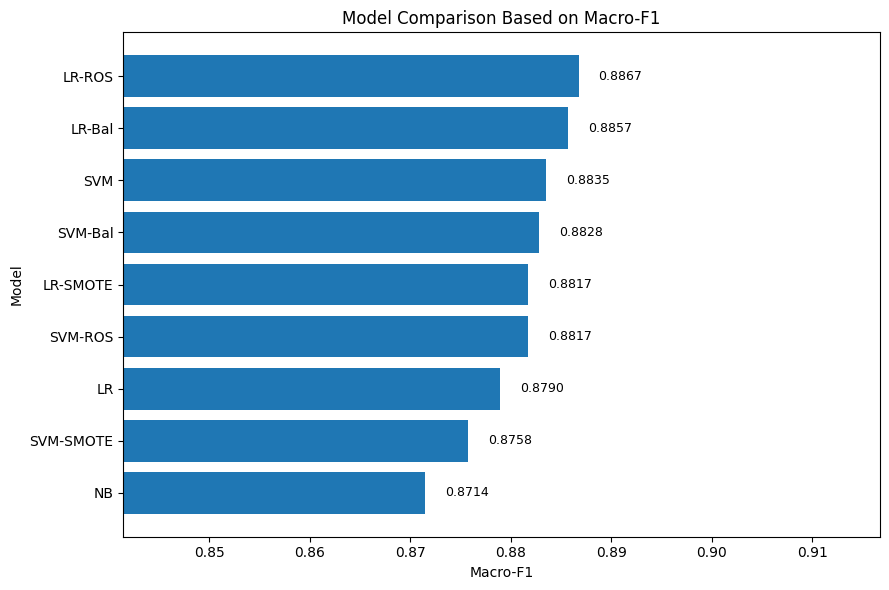

Figure disimpan ke: d:\Github\kingshot-review-sentiment-analysis\outputs\figures\imbalance_model_f1_macro_comparison_clean.png


In [8]:
plot_df = evaluation_df.sort_values("f1_macro", ascending=True)

plt.figure(figsize=(9, 6))
bars = plt.barh(plot_df["short_model"], plot_df["f1_macro"])

plt.title("Model Comparison Based on Macro-F1")
plt.xlabel("Macro-F1")
plt.ylabel("Model")
plt.xlim(max(0, plot_df["f1_macro"].min() - 0.03), min(1.0, plot_df["f1_macro"].max() + 0.03))

for bar, value in zip(bars, plot_df["f1_macro"]):
    plt.text(
        value + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

f1_fig = FIGURE_DIR / "imbalance_model_f1_macro_comparison_clean.png"
plt.savefig(f1_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure disimpan ke: {f1_fig}")


## 9. Select the Best Model Before and After Imbalance Handling

The notebook automatically selects:

```text
Before imbalance handling:
the best baseline model without balancing

After imbalance handling:
the best model from class weighting, Random OverSampling, or SMOTE experiments
```

Model selection is based on `f1_macro`, followed by `recall_positive`, then `accuracy`.


In [9]:
baseline_models = [
    "Logistic Regression",
    "Linear SVM",
    "Naive Bayes"
]

imbalance_models = [
    "Logistic Regression Balanced",
    "Linear SVM Balanced",
    "Logistic Regression RandomOverSampler",
    "Linear SVM RandomOverSampler",
    "Logistic Regression SMOTE",
    "Linear SVM SMOTE"
]

before_df = evaluation_df[evaluation_df["model"].isin(baseline_models)].copy()
after_df = evaluation_df[evaluation_df["model"].isin(imbalance_models)].copy()

before_best = before_df.sort_values(
    by=["f1_macro", "recall_positive", "accuracy"],
    ascending=False
).iloc[0]

after_best = after_df.sort_values(
    by=["f1_macro", "recall_positive", "accuracy"],
    ascending=False
).iloc[0]

before_model_name = before_best["model"]
after_model_name = after_best["model"]

print("Best before imbalance handling:", before_model_name)
print("Best after imbalance handling :", after_model_name)

comparison_metrics_df = pd.DataFrame({
    "metric": ["Accuracy", "Macro-F1", "Recall Negative", "Recall Positive"],
    "before": [
        before_best["accuracy"],
        before_best["f1_macro"],
        before_best["recall_negative"],
        before_best["recall_positive"]
    ],
    "after": [
        after_best["accuracy"],
        after_best["f1_macro"],
        after_best["recall_negative"],
        after_best["recall_positive"]
    ]
})

comparison_metrics_df["change"] = comparison_metrics_df["after"] - comparison_metrics_df["before"]

display(comparison_metrics_df)


Best before imbalance handling: Linear SVM
Best after imbalance handling : Logistic Regression RandomOverSampler


,metric,before,after,change
0,Accuracy,0.895747,0.897822,0.002075
1,Macro-F1,0.883505,0.886743,0.003238
2,Recall Negative,0.941553,0.934347,-0.007206
3,Recall Positive,0.811487,0.830633,0.019146


## 10. Visualization 2 — Performance Before vs After Imbalance Handling

This figure compares the selected baseline model and the selected imbalance-handled model across key evaluation metrics.


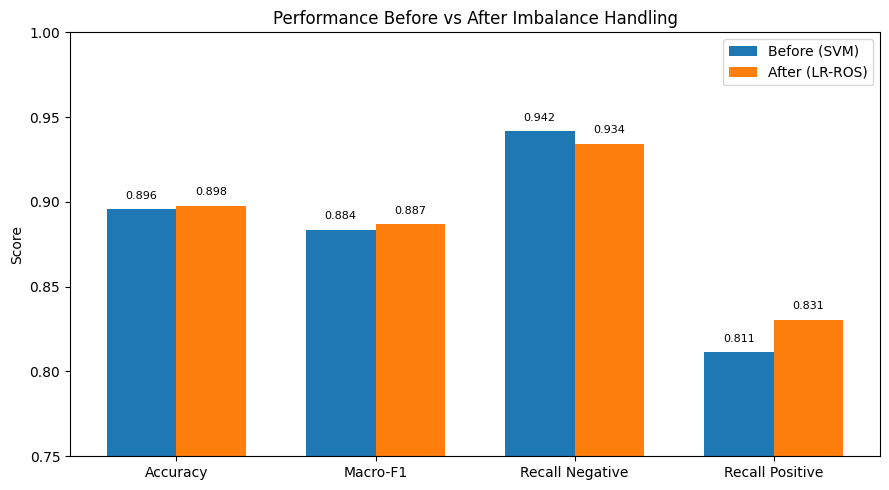

Figure disimpan ke: d:\Github\kingshot-review-sentiment-analysis\outputs\figures\before_after_imbalance_metrics.png


In [10]:
x = np.arange(len(comparison_metrics_df))
width = 0.35

plt.figure(figsize=(9, 5))

bars_before = plt.bar(
    x - width / 2,
    comparison_metrics_df["before"],
    width=width,
    label=f"Before ({model_short_names.get(before_model_name, before_model_name)})"
)

bars_after = plt.bar(
    x + width / 2,
    comparison_metrics_df["after"],
    width=width,
    label=f"After ({model_short_names.get(after_model_name, after_model_name)})"
)

plt.xticks(x, comparison_metrics_df["metric"])
plt.ylabel("Score")
plt.title("Performance Before vs After Imbalance Handling")
plt.ylim(0.75, 1.0)
plt.legend()

for bars in [bars_before, bars_after]:
    for bar in bars:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.005,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

before_after_fig = FIGURE_DIR / "before_after_imbalance_metrics.png"
plt.savefig(before_after_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure disimpan ke: {before_after_fig}")


## 11. Visualization 3 — Metric Changes After Imbalance Handling

This figure highlights whether imbalance handling improves or reduces each evaluation metric.


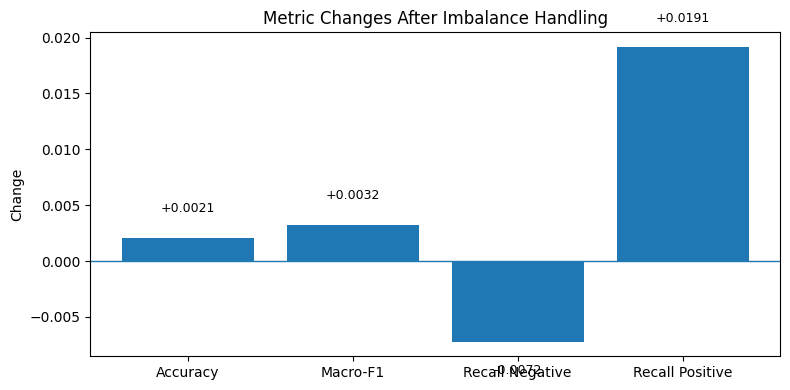

Figure disimpan ke: d:\Github\kingshot-review-sentiment-analysis\outputs\figures\metric_changes_after_imbalance.png


In [11]:
delta_df = comparison_metrics_df.copy()

plt.figure(figsize=(8, 4))
bars = plt.bar(delta_df["metric"], delta_df["change"])
plt.axhline(0, linewidth=1)

plt.ylabel("Change")
plt.title("Metric Changes After Imbalance Handling")

for bar, value in zip(bars, delta_df["change"]):
    if value >= 0:
        va = "bottom"
        y = value + 0.002
    else:
        va = "top"
        y = value - 0.002

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{value:+.4f}",
        ha="center",
        va=va,
        fontsize=9
    )

plt.tight_layout()

delta_fig = FIGURE_DIR / "metric_changes_after_imbalance.png"
plt.savefig(delta_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure disimpan ke: {delta_fig}")


## 12. Visualization 4 — Confusion Matrix Before vs After Imbalance Handling

The confusion matrices show how imbalance handling affects positive and negative class predictions.


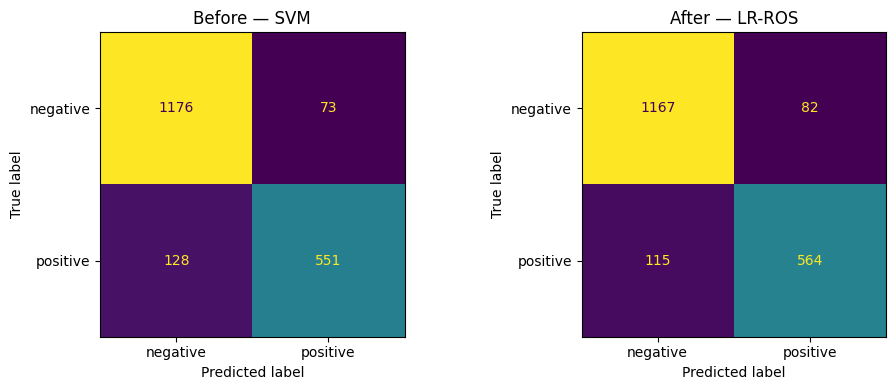

Figure disimpan ke: d:\Github\kingshot-review-sentiment-analysis\outputs\figures\confusion_matrix_before_after_imbalance.png


In [12]:
before_pred = predictions[before_model_name]
after_pred = predictions[after_model_name]

before_cm = confusion_matrix(y_test, before_pred, labels=["negative", "positive"])
after_cm = confusion_matrix(y_test, after_pred, labels=["negative", "positive"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before_disp = ConfusionMatrixDisplay(
    confusion_matrix=before_cm,
    display_labels=["negative", "positive"]
)

after_disp = ConfusionMatrixDisplay(
    confusion_matrix=after_cm,
    display_labels=["negative", "positive"]
)

before_disp.plot(values_format="d", ax=axes[0], colorbar=False)
axes[0].set_title(f"Before — {model_short_names.get(before_model_name, before_model_name)}")

after_disp.plot(values_format="d", ax=axes[1], colorbar=False)
axes[1].set_title(f"After — {model_short_names.get(after_model_name, after_model_name)}")

plt.tight_layout()

cm_before_after_fig = FIGURE_DIR / "confusion_matrix_before_after_imbalance.png"
plt.savefig(cm_before_after_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure disimpan ke: {cm_before_after_fig}")


## 13. Confusion Matrix of the Best Imbalance-Handled Model

This figure provides a focused view of the final selected model after imbalance handling.


Best model setelah imbalance handling:
Logistic Regression RandomOverSampler


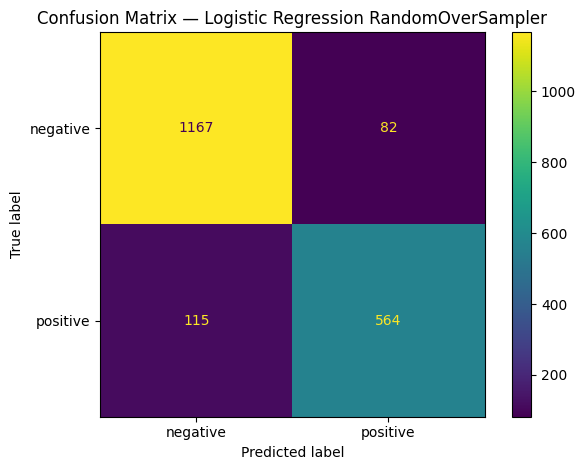

Confusion matrix disimpan ke: d:\Github\kingshot-review-sentiment-analysis\outputs\figures\imbalance_confusion_matrix_best_model.png


In [13]:
best_model_name = after_model_name
best_model = trained_models[best_model_name]

print("Best model setelah imbalance handling:")
print(best_model_name)

best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred, labels=["negative", "positive"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "positive"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()

cm_fig = FIGURE_DIR / "imbalance_confusion_matrix_best_model.png"
plt.savefig(cm_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"Confusion matrix disimpan ke: {cm_fig}")


## 14. Final Model Selection Summary

The final summary table records the best model before and after imbalance handling, along with the key evaluation metrics.


In [14]:
cv_lookup = cv_results_df.set_index("model")

final_summary_rows = []

for label, selected_model in [
    ("Before imbalance handling", before_model_name),
    ("After imbalance handling", after_model_name)
]:
    eval_row = evaluation_df[evaluation_df["model"] == selected_model].iloc[0]
    cv_row = cv_lookup.loc[selected_model]

    final_summary_rows.append({
        "stage": label,
        "model": selected_model,
        "short_model": model_short_names.get(selected_model, selected_model),
        "accuracy": eval_row["accuracy"],
        "macro_f1": eval_row["f1_macro"],
        "weighted_f1": eval_row["f1_weighted"],
        "recall_negative": eval_row["recall_negative"],
        "recall_positive": eval_row["recall_positive"],
        "cv_macro_f1_mean": cv_row["f1_macro_mean"],
        "cv_macro_f1_std": cv_row["f1_macro_std"]
    })

final_model_summary_df = pd.DataFrame(final_summary_rows)

display(final_model_summary_df)
display(comparison_metrics_df)


,stage,model,short_model,accuracy,macro_f1,weighted_f1,recall_negative,recall_positive,cv_macro_f1_mean,cv_macro_f1_std
0,Before imbalance handling,Linear SVM,SVM,0.895747,0.883505,0.894670,0.941553,0.811487,0.896433,0.006133
1,After imbalance handling,Logistic Regression RandomOverSampler,LR-ROS,0.897822,0.886743,0.897215,0.934347,0.830633,0.899546,0.007553


,metric,before,after,change
0,Accuracy,0.895747,0.897822,0.002075
1,Macro-F1,0.883505,0.886743,0.003238
2,Recall Negative,0.941553,0.934347,-0.007206
3,Recall Positive,0.811487,0.830633,0.019146


## 15. Save Output Tables

All experiment tables are saved for reporting and article writing.


In [15]:
comparison_file = TABLE_DIR / "imbalance_model_comparison.xlsx"
reports_file = TABLE_DIR / "imbalance_classification_reports.xlsx"
cv_file = TABLE_DIR / "imbalance_cross_validation_results.xlsx"
final_summary_file = TABLE_DIR / "final_model_selection_summary.xlsx"

evaluation_df.to_excel(comparison_file, index=False)
classification_reports_df.to_excel(reports_file, index=False)
cv_results_df.to_excel(cv_file, index=False)

with pd.ExcelWriter(final_summary_file) as writer:
    final_model_summary_df.to_excel(writer, sheet_name="final_summary", index=False)
    comparison_metrics_df.to_excel(writer, sheet_name="before_after_metrics", index=False)
    class_distribution.to_excel(writer, sheet_name="class_distribution", index=False)

print(f"Model comparison       : {comparison_file}")
print(f"Classification reports : {reports_file}")
print(f"Cross validation       : {cv_file}")
print(f"Final summary          : {final_summary_file}")


Model comparison       : d:\Github\kingshot-review-sentiment-analysis\outputs\tables\imbalance_model_comparison.xlsx
Classification reports : d:\Github\kingshot-review-sentiment-analysis\outputs\tables\imbalance_classification_reports.xlsx
Cross validation       : d:\Github\kingshot-review-sentiment-analysis\outputs\tables\imbalance_cross_validation_results.xlsx
Final summary          : d:\Github\kingshot-review-sentiment-analysis\outputs\tables\final_model_selection_summary.xlsx


## 16. Notes

```text
To evaluate the effect of class imbalance, this study compared baseline models without balancing, models with class_weight="balanced", Random OverSampling, and SMOTE. All models used TF-IDF n-gram representations. Model performance was evaluated using accuracy, precision, recall, macro-F1, weighted-F1, confusion matrix, and 5-fold stratified cross-validation.
```

SMOTE:

```text
SMOTE was included as an additional experiment because text data represented by TF-IDF is sparse and high-dimensional. Therefore, SMOTE results were compared with class weighting and oversampling to identify the most stable imbalance handling strategy.
```

```text
The before-after visualization was used to examine the performance trade-off after imbalance handling. The results show whether balancing improves minority-class sensitivity while maintaining overall classification performance.
```

```text
Figure 1. Class distribution of the processed Kingshot review dataset.
Figure 2. Macro-F1 comparison across baseline and imbalance-handled models.
Figure 3. Model performance before and after imbalance handling.
Figure 4. Confusion matrix comparison before and after imbalance handling.
Figure 5. Final confusion matrix of the selected model.
```
